In [126]:
from databricks.sql import connect
from dotenv import load_dotenv
import pandas as pd
import os

In [127]:
def fetch_database() -> pd.DataFrame:
    load_dotenv()
    connection = connect(
        server_hostname=os.getenv("DATABRICKS_SERVER_HOSTNAME"),
        http_path=os.getenv("DATABRICKS_HTTP_PATH"),
        access_token=os.getenv("DATABRICKS_ACCESS_TOKEN")
    )
    query = """
    WITH cte AS (
        SELECT
            ueid,
            session_id,
            ROUND(AVG(avgcqi), 2) AS avgcqi,
            ROUND(AVG(avgmcs), 2) AS avgmcs,
            ROUND(AVG(rptri), 2) AS avgri,
            ROUND(AVG(rv0_tx), 2) AS avg_rv0_tx,
            ROUND(AVG(tbler), 2) AS tbler
        FROM `du_stats`.`gold`.`enriched_histo`
        GROUP BY ueid, session_id
    )
    SELECT
        ueid,
        session_id,
        avgcqi,
        avgmcs,
        avgri,
        avg_rv0_tx,
        tbler,
        CASE
            WHEN ueid IN (17019, 17020, 17025, 17204, 17205, 17018, 17206, 17209, 17017, 17021, 17022) THEN 'Good UE'
            WHEN ueid IN (17208, 17024) THEN 'No_TX'
            WHEN ueid IN (17123, 17207) THEN 'Channel Quality Bad'
            WHEN ueid IN (17164, 17023) THEN 'MCS Limitation'
        END AS session_rca
    FROM cte
    """
    df = pd.read_sql(query, connection)
    return df

In [128]:
df = fetch_database()
print(df.head())
print('\n================\n')
print(df.info())

/var/folders/jy/z7hpn3yd3x9cr2kbxhjw27700000gn/T/ipykernel_26482/3109051539.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


    ueid  session_id  avgcqi  avgmcs  avgri  avg_rv0_tx  tbler session_rca
0  17017       90385   12.46   13.84   2.75        7.75   0.00     Good UE
1  17017       90010   13.95   13.63   2.37        8.00   0.00     Good UE
2  17204      361959   13.47    8.69   2.20        8.00   2.63     Good UE
3  17022      126160   13.41   13.60   2.87        7.78   0.00     Good UE
4  17018      198531    9.33   24.08   2.51        6.00   0.00     Good UE


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296208 entries, 0 to 296207
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ueid         296208 non-null  int64  
 1   session_id   296208 non-null  int64  
 2   avgcqi       296208 non-null  float64
 3   avgmcs       296208 non-null  float64
 4   avgri        296208 non-null  float64
 5   avg_rv0_tx   296208 non-null  float64
 6   tbler        296208 non-null  float64
 7   session_rca  296208 non-null  object 
dtypes: 

In [129]:
df.to_csv('du_stats_rca.csv', index=False)

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('du_stats_rca.csv')

## UE distribution for different categories

In [131]:
good_ues = [17021, 17022, 17019, 17020, 17025, 17204, 17205, 17018, 17206, 17209, 17017]
bad_channel_ues = [17123, 17207]
mcs_limitation_ues = [17164, 17023]
no_tx_ues = [17208, 17024]

### Distribution for Good UEs

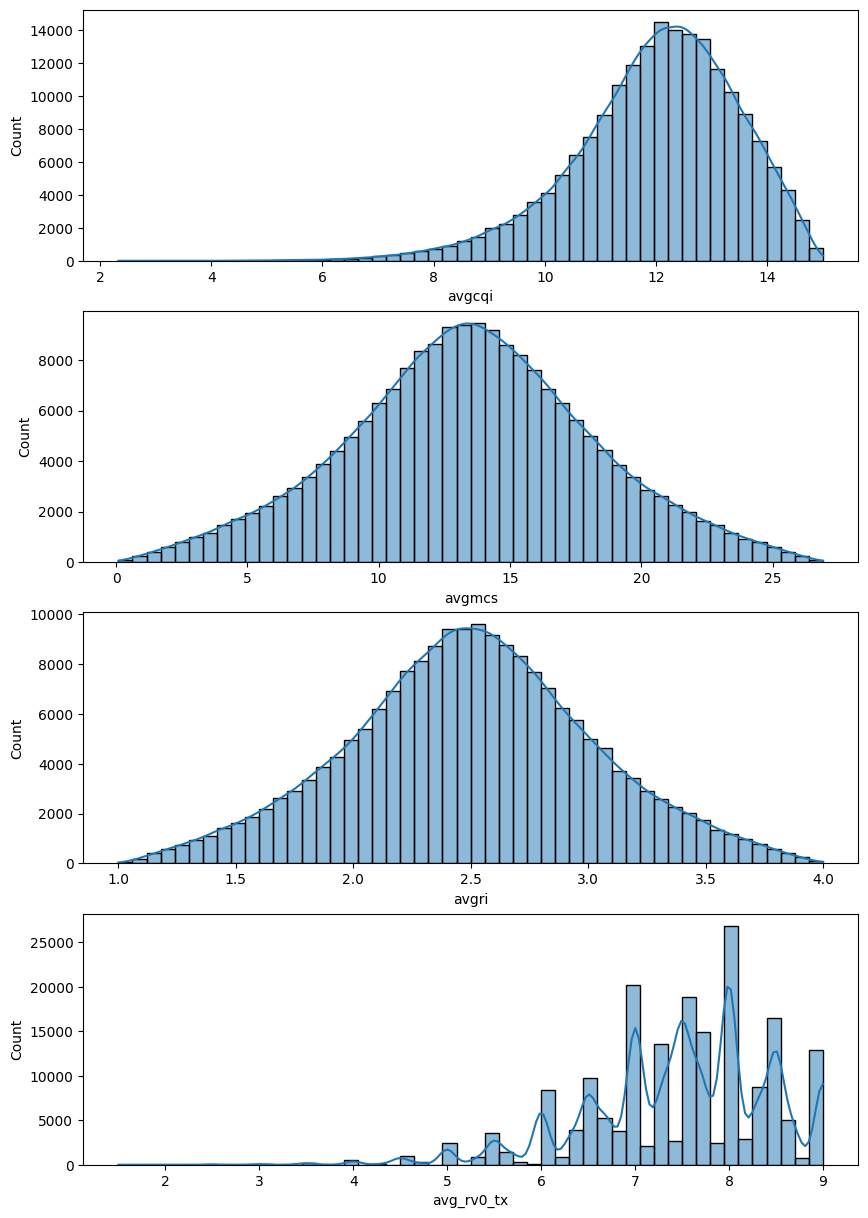

In [132]:
good_ue_df = df[df['ueid'].isin(good_ues)]
plt.figure(figsize=(10,15))
plt.subplot(411)
sns.histplot(data=good_ue_df, x='avgcqi', bins=50, kde=True)
plt.subplot(412)
sns.histplot(data=good_ue_df, x='avgmcs', bins=50, kde=True)
plt.subplot(413)
sns.histplot(data=good_ue_df, x='avgri', bins=50, kde=True)
plt.subplot(414)
sns.histplot(data=good_ue_df, x='avg_rv0_tx', bins=50, kde=True)
plt.show()

### Distribution of UEs with MCS Limitation

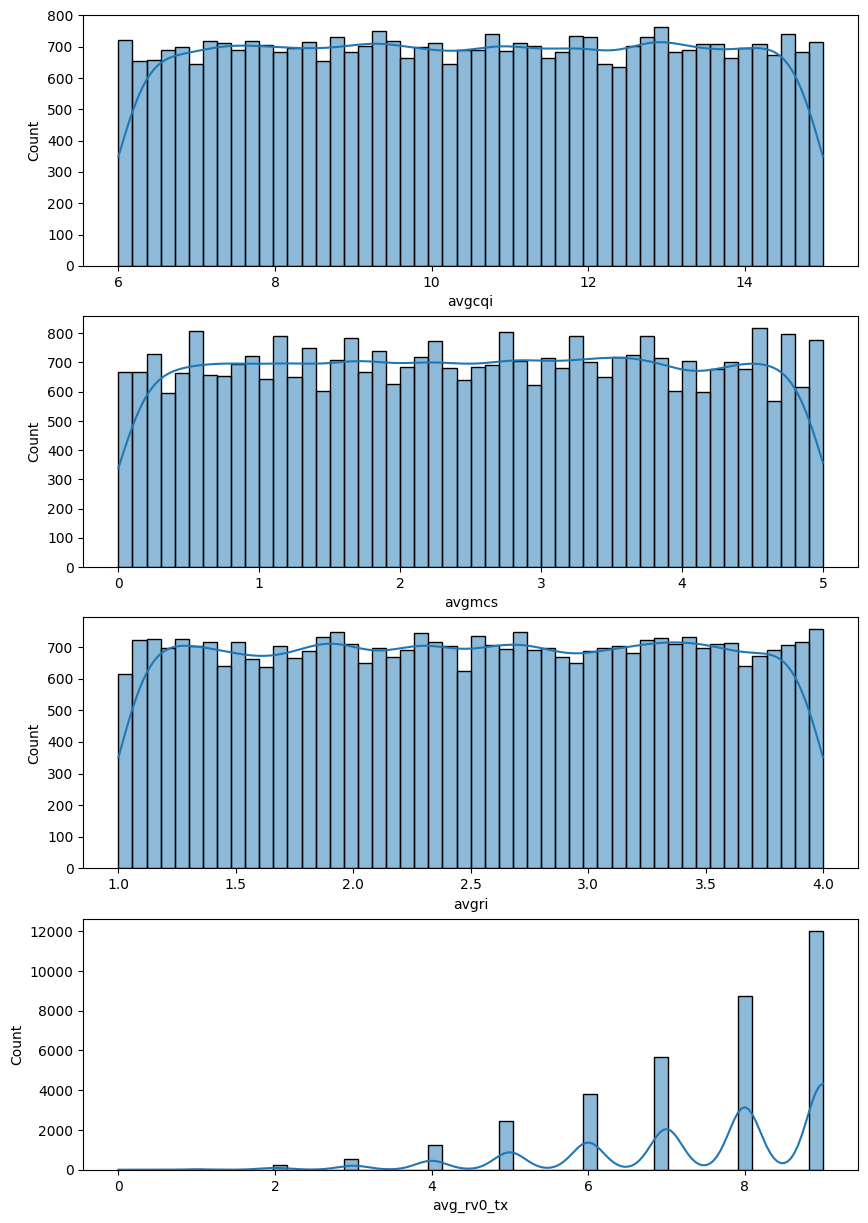

In [133]:
good_ue_df = df[df['ueid'].isin(mcs_limitation_ues)]
plt.figure(figsize=(10,15))
plt.subplot(411)
sns.histplot(data=good_ue_df, x='avgcqi', bins=50, kde=True)
plt.subplot(412)
sns.histplot(data=good_ue_df, x='avgmcs', bins=50, kde=True)
plt.subplot(413)
sns.histplot(data=good_ue_df, x='avgri', bins=50, kde=True)
plt.subplot(414)
sns.histplot(data=good_ue_df, x='avg_rv0_tx', bins=50, kde=True)
plt.show()

### Distribution of UE's with Bad Channel Quality

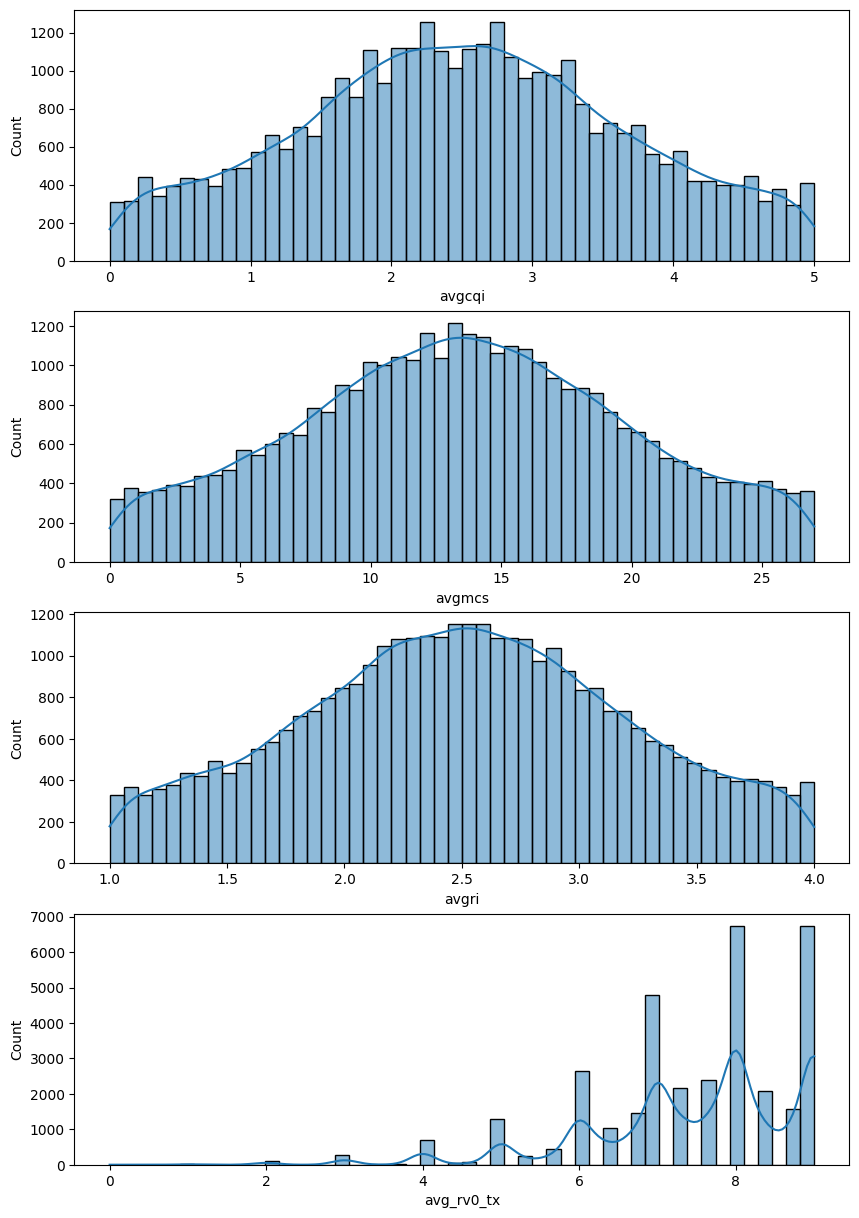

In [134]:
good_ue_df = df[df['ueid'].isin(bad_channel_ues)]
plt.figure(figsize=(10,15))
plt.subplot(411)
sns.histplot(data=good_ue_df, x='avgcqi', bins=50, kde=True)
plt.subplot(412)
sns.histplot(data=good_ue_df, x='avgmcs', bins=50, kde=True)
plt.subplot(413)
sns.histplot(data=good_ue_df, x='avgri', bins=50, kde=True)
plt.subplot(414)
sns.histplot(data=good_ue_df, x='avg_rv0_tx', bins=50, kde=True)
plt.show()

### Distribution of UEs with No Transmission

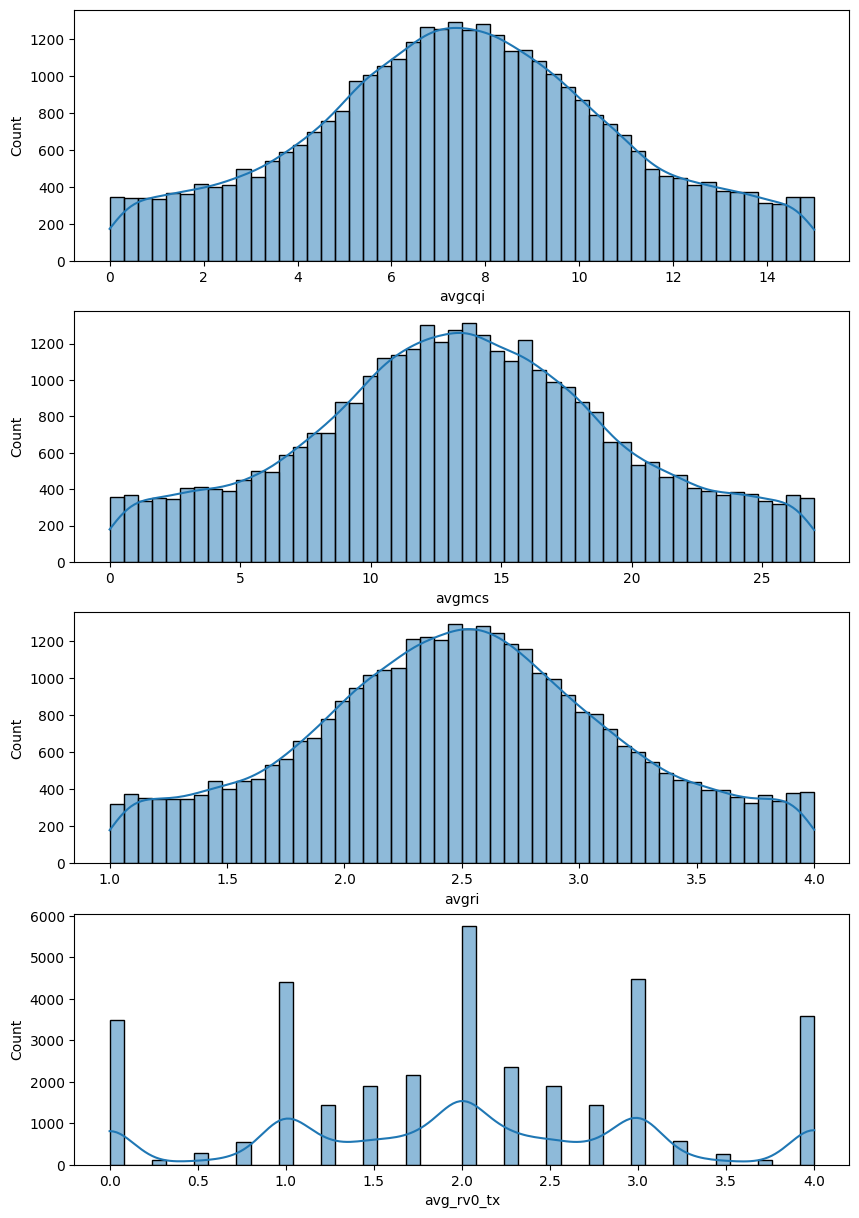

In [135]:
good_ue_df = df[df['ueid'].isin(no_tx_ues)]
plt.figure(figsize=(10,15))
plt.subplot(411)
sns.histplot(data=good_ue_df, x='avgcqi', bins=50, kde=True)
plt.subplot(412)
sns.histplot(data=good_ue_df, x='avgmcs', bins=50, kde=True)
plt.subplot(413)
sns.histplot(data=good_ue_df, x='avgri', bins=50, kde=True)
plt.subplot(414)
sns.histplot(data=good_ue_df, x='avg_rv0_tx', bins=50, kde=True)
plt.show()